In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import random

In [2]:
def energia(rede, J, B = 0):
  somaJ = 0
  somaB = 0
  for i in range(len(rede)): #linha
    for j in range(len(rede[0])): #coluna
    #calcula cada parte do somatório
      somaB += rede[i][j]
      somaJ += rede[i][j] * (rede[i][(j + 1) % len(rede[j])] + rede[(i + 1) % len(rede)][j])
  return (-J * somaJ) + (B *somaB) # multiplica pelas constantes no final

In [20]:
def diff_energy(rede, i, j, J, B):
  #diferença maxima segundo cap 3.1 pag 46
  # e mais eficiente que recalcular toda a energia e tirar a diferença
  vizinhos = (
      rede[(i + 1) % len(rede), j] +
      rede[(i - 1) % len(rede), j] +
      rede[i, (j + 1) % len(rede[j])] +
      rede[i, (j - 1) % len(rede[j])]
  )
  return (2 * J * rede[i, j] * vizinhos) + (B * (-rede[i][j]))

In [4]:
def metropolis(rede, nPassos, J, B,T, k_b = 1, n_termalizacao=10):
  magnetizacoes = []
  E_tot = 0
  for passo in range(nPassos):
    for _ in range(len(rede) * len(rede[0])): # Cada passo MC tem N*N tentativas de flip
        # Seleciona aleatoriamente um spin para tentar flipar
        i = random.randint(0, len(rede)-1)
        j = random.randint(0, len(rede[0])-1)
        dE = diff_energy(rede, i, j, J, B) #usando essa função por ser mais otimizada que calcular toda a energia
        #calcula a probabilidade
        p = np.exp(-dE / (k_b * T))
        # Critério de Metropolis
        if p > 1 or random.random() < p:#
            rede[i, j] *= -1
            E_tot += dE

    # Após N×N tentativas, registra a magnetização média
    magnetizacoes.append(np.mean(rede))

  # Remove os primeiros passos (fase de termalização)
  mag_equilibrio = magnetizacoes[n_termalizacao:]

  # Exibe energia final
  print(f"Energia final do sistema: {float(E_tot):.2f}")

  # Gráfico da magnetização ao longo do tempo
  plt.figure(figsize=(10, 4))
  plt.plot(range(n_termalizacao, n_termalizacao + len(mag_equilibrio)), mag_equilibrio,
            label='Magnetização média', color='blue')
  plt.xlabel('Passo de Monte Carlo')
  plt.ylabel('Spin médio')
  plt.title('Evolução da Magnetização (após termalização)')
  plt.grid(True)
  plt.legend()
  plt.tight_layout()
  plt.show()

  return mag_equilibrio, E_tot, rede

# Exercicio A

In [5]:
#declarando a rede de spins 100X100
# rede = np.random.choice([-1, 1], size=(100, 100))
# rede

In [6]:
# np.savetxt("rede.txt", rede, fmt="%d", delimiter=",")
rede = np.loadtxt("rede.txt", delimiter=",", dtype=int)

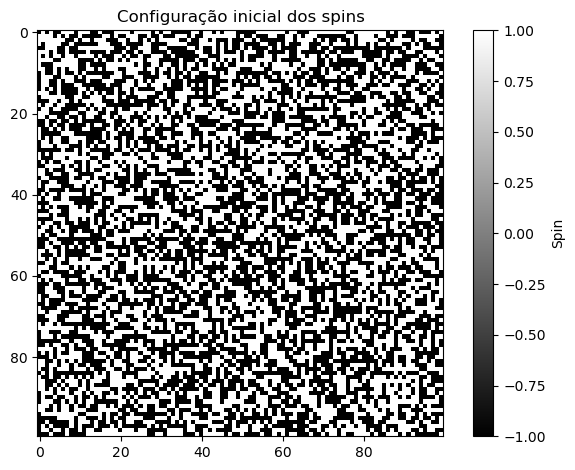

In [7]:
# Visualização da configuração inicial dos spins
plt.imshow(rede, cmap='gray', interpolation='nearest')
plt.title('Configuração inicial dos spins')
plt.colorbar(label='Spin')
plt.tight_layout()
plt.show()

In [8]:
E_0 = energia(rede, J=1, B=0) #para testar
print("Energia inicial:", E_0)

Energia inicial: 60


Energia final do sistema: -17364.00


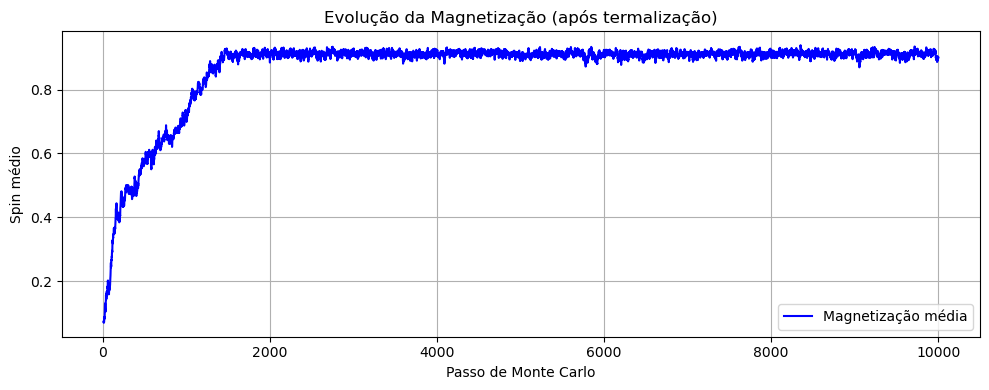

In [9]:
mag_equilibrio, E_t, rede_pos = metropolis(rede, 10000, J=1, B=0, T = 2.0)

# Exercicio B

Energia final do sistema: -20024.00


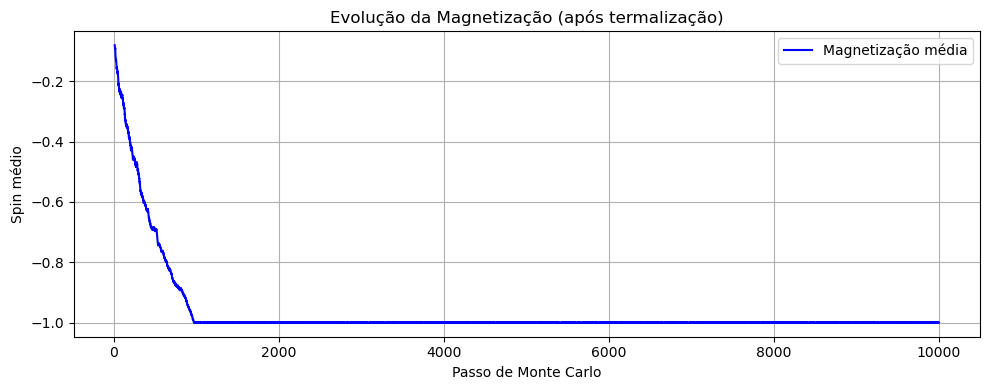

In [10]:
rede = np.loadtxt("rede.txt", delimiter=",", dtype=int)
mag_equilibrio, E_t, rede_pos = metropolis(rede, 10000, J=1, B=0, T = 1.0)

Energia final do sistema: -8164.00


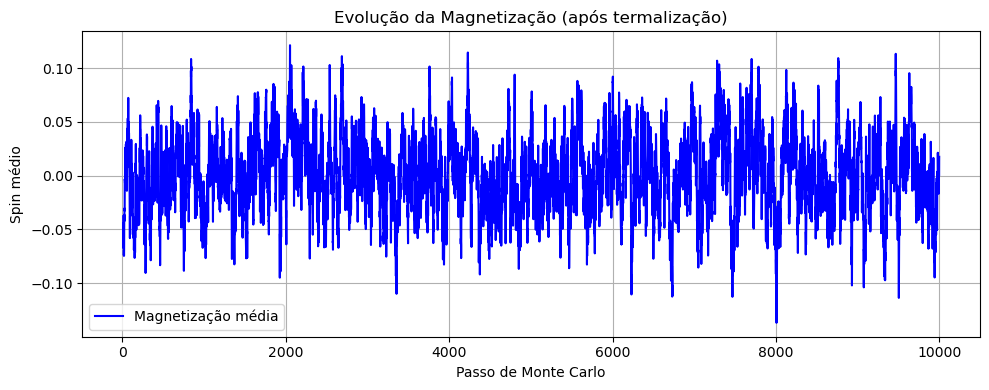

In [11]:
rede = np.loadtxt("rede.txt", delimiter=",", dtype=int)
mag_equilibrio, E_t, rede_pos = metropolis(rede, 10000, J=1, B=0, T = 3.0)

Em T=1, o sistema estabilizou em -1 após cerca de 1000 passos. A quantidade de passos para estabilização varia de acordo com a matriz aleatória de spins. Já em T=2.0, considerando o resultado do exercicio anterior para a mesma matriz, o sistema ainda apresenta uma "estabilização" antes de 2000 passos, mas com mais oscilações, indicando que está próximo da temperatura crítica. Já em T=3, o sistema se mantém oscilando próximo de zero, o que indica que esse valor de temperatura é maior que a temperatura crítica.

# Exercício C

In [12]:
rede_ones = np.ones((100,100), int)
rede_ones

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]])

Energia inicial: -20000
Energia final do sistema: 2448.00


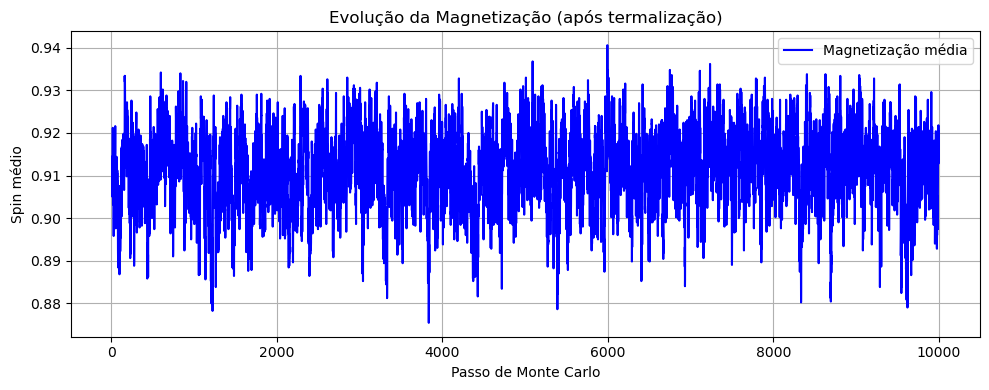

In [13]:
E_0 = energia(rede_ones, J=1, B=0) #para testar
print("Energia inicial:", E_0)
mag_equilibrio, E_t, rede_pos = metropolis(rede_ones, 10000, J=1, B=0, T = 2.0)

dado que a condição inicial era de todos os spins up, isso já leva a menor energia. O metropolis então gera clusters de configurações de spin e é um algoritmo que pode cair em mínimos locais.

# Exercício D

Energia final do sistema: -11120.00


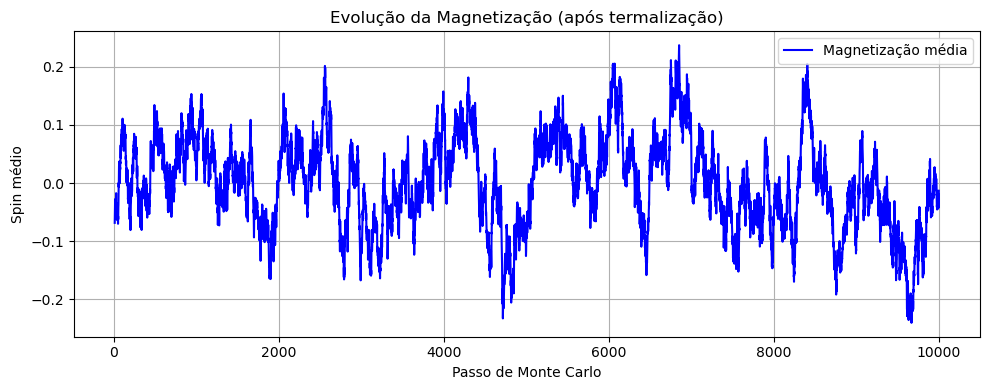

In [14]:
rede = np.loadtxt("rede.txt", delimiter=",", dtype=int)
mag_equilibrio, E_t, rede_pos = metropolis(rede, 10000, J=1, B=0, T = 2.5)

Energia final do sistema: -13792.00


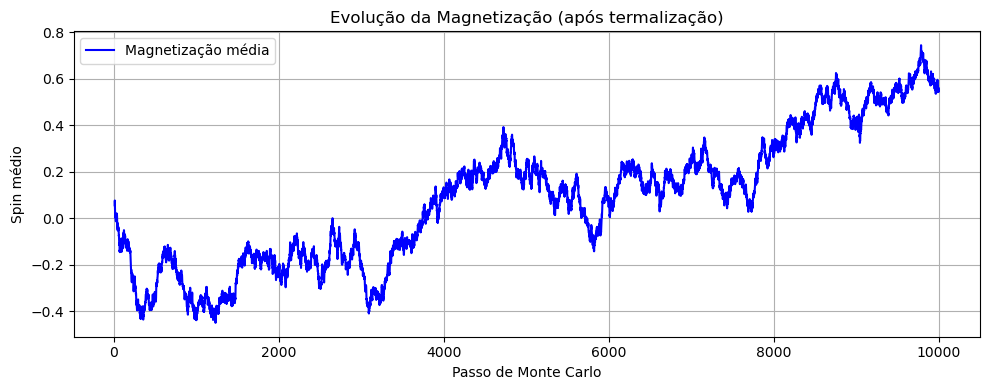

In [15]:
rede = np.loadtxt("rede.txt", delimiter=",", dtype=int)
mag_equilibrio, E_t, rede_pos = metropolis(rede, 10000, J=1, B=0, T = 2.3)

A temperatura crítica é aproximadamente 2.3

# Exercício E

Energia final do sistema: -5425.50


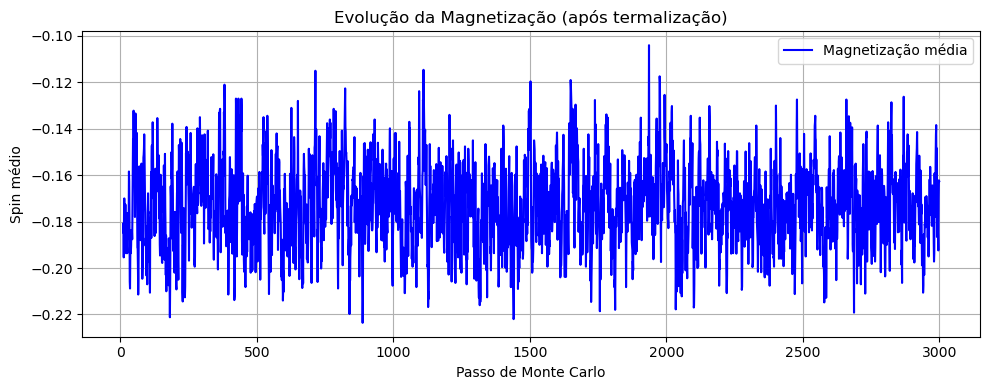

In [25]:
rede = np.loadtxt("rede.txt", delimiter=",", dtype=int)
Tc = 2.3
mag_equilibrio, E_t, rede_pos = metropolis(rede, 3000, J=1, B=0.5, T = 2*Tc)